# 🫁 End-to-End Chest Disease Classification
### VGG16 Transfer Learning · MLflow / DagsHub · Modular Pipeline

**Pipeline Stages:**
1. Environment Setup & Secrets
2. Write Project Source Files
3. Stage 1 — Data Ingestion
4. Stage 2 — Prepare Base Model (VGG16)
5. Stage 3 — Model Training
6. Stage 4 — Model Evaluation + MLflow
7. Prediction Demo
8. Package & Download Artifacts

> **GPU recommended.** Go to *Runtime → Change runtime type → GPU* before running.

---
## 🔧 Section 1 — Environment Setup & Secrets

In [1]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ set False to log locally inside Colab

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


In [2]:
# ── Install dependencies ───────────────────────────────────────────────────────
# Colab ships TF 2.x; pin the extras the project needs.
!pip install -q \
    gdown \
    mlflow\
    python-box \
    ensure\
    pyYAML \
    tqdm \
    joblib \
    types-PyYAML

print('✅ Packages installed.')

✅ Packages installed.


In [3]:
# ── Create and cd into the project working directory ──────────────────────────
import os

PROJECT_DIR = '/content/chest-disease-project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f'✅ Working directory: {os.getcwd()}')

✅ Working directory: /content/chest-disease-project


---
## 📝 Section 2 — Write Project Source Files
All `.py` files are written inline so the notebook is fully self-contained.

In [4]:
import os, pathlib

# ── Directory skeleton ─────────────────────────────────────────────────────────
dirs = [
    'src/cnnClassifier',
    'src/cnnClassifier/components',
    'src/cnnClassifier/config',
    'src/cnnClassifier/constants',
    'src/cnnClassifier/entity',
    'src/cnnClassifier/pipeline',
    'src/cnnClassifier/utils',
    'config',
    'artifacts',
    'logs',
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print('✅ Directories created.')

✅ Directories created.


In [5]:
# ── config/config.yaml ────────────────────────────────────────────────────────
config_yaml = """\
artifacts_root: artifacts

data_ingestion:
  root_dir: artifacts/data_ingestion
  source_URL: https://drive.google.com/file/d/1z0mreUtRmR-P-magILsDR3T7M6IkGXtY/view?usp=sharing
  local_data_file: artifacts/data_ingestion/data.zip
  unzip_dir: artifacts/data_ingestion

prepare_base_model:
  root_dir: artifacts/prepare_base_model
  base_model_path: artifacts/prepare_base_model/base_model.h5
  updated_base_model_path: artifacts/prepare_base_model/base_model_updated.h5

training:
  root_dir: artifacts/training
  trained_model_path: artifacts/training/model.h5
"""
pathlib.Path('config/config.yaml').write_text(config_yaml)
print('✅ config/config.yaml written.')

✅ config/config.yaml written.


In [6]:
# ── params.yaml ───────────────────────────────────────────────────────────────
params_yaml = """\
AUGMENTATION: True
IMAGE_SIZE: [224, 224, 3]   # VGG16 input size
BATCH_SIZE: 16
INCLUDE_TOP: False
EPOCHS: 3               # increase for better accuracy
CLASSES: 2
WEIGHTS: imagenet
LEARNING_RATE: 0.01
"""
pathlib.Path('params.yaml').write_text(params_yaml)
print('✅ params.yaml written.')

✅ params.yaml written.


In [7]:
# ── setup.py ──────────────────────────────────────────────────────────────────
setup_py = """\
import setuptools

__version__ = "0.0.0"

REPO_NAME   = "Chest-Cancer-Classification-Project"
AUTHOR_USER_NAME = "entbappy"
SRC_REPO    = "cnnClassifier"
AUTHOR_EMAIL = "entbappy73@gmail.com"

setuptools.setup(
    name=SRC_REPO,
    version=__version__,
    author=AUTHOR_USER_NAME,
    author_email=AUTHOR_EMAIL,
    description="CNN-based Chest Disease Classifier",
    package_dir={"": "src"},
    packages=setuptools.find_packages(where="src"),
)
"""
pathlib.Path('setup.py').write_text(setup_py)
print('✅ setup.py written.')

✅ setup.py written.


In [8]:
# ── __init__.py files ─────────────────────────────────────────────────────────

# Package logger (main package __init__)
pkg_init = """\
import os
import sys
import logging

logging_str = "[%(asctime)s: %(levelname)s: %(module)s: %(message)s]"

log_dir = "logs"
log_filepath = os.path.join(log_dir, "running_logs.log")
os.makedirs(log_dir, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format=logging_str,
    handlers=[
        logging.FileHandler(log_filepath),
        logging.StreamHandler(sys.stdout),
    ],
)

logger = logging.getLogger("cnnClassifierLogger")
"""
pathlib.Path('src/cnnClassifier/__init__.py').write_text(pkg_init)

# Empty __init__ stubs for sub-packages
for stub in [
    'src/cnnClassifier/components/__init__.py',
    'src/cnnClassifier/config/__init__.py',
    'src/cnnClassifier/constants/__init__.py',
    'src/cnnClassifier/entity/__init__.py',
    'src/cnnClassifier/pipeline/__init__.py',
    'src/cnnClassifier/utils/__init__.py',
]:
    pathlib.Path(stub).write_text('')

print('✅ __init__.py files written.')

✅ __init__.py files written.


In [9]:
# ── constants/__init__.py ─────────────────────────────────────────────────────
constants_init = """\
from pathlib import Path

CONFIG_FILE_PATH = Path("config/config.yaml")
PARAMS_FILE_PATH = Path("params.yaml")
"""
pathlib.Path('src/cnnClassifier/constants/__init__.py').write_text(constants_init)
print('✅ constants/__init__.py written.')

✅ constants/__init__.py written.


In [10]:
# ── entity/config_entity.py ───────────────────────────────────────────────────
config_entity = """\
from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class DataIngestionConfig:
    root_dir: Path
    source_URL: str
    local_data_file: Path
    unzip_dir: Path


@dataclass(frozen=True)
class PrepareBaseModelConfig:
    root_dir: Path
    base_model_path: Path
    updated_base_model_path: Path
    params_image_size: list
    params_learning_rate: float
    params_include_top: bool
    params_weights: str
    params_classes: int


@dataclass(frozen=True)
class TrainingConfig:
    root_dir: Path
    trained_model_path: Path
    updated_base_model_path: Path
    training_data: Path
    params_epochs: int
    params_batch_size: int
    params_is_augmentation: bool
    params_image_size: list


@dataclass(frozen=True)
class EvaluationConfig:
    path_of_model: Path
    training_data: Path
    all_params: dict
    mlflow_uri: str
    params_image_size: list
    params_batch_size: int
"""
pathlib.Path('src/cnnClassifier/entity/config_entity.py').write_text(config_entity)
print('✅ entity/config_entity.py written.')

✅ entity/config_entity.py written.


In [11]:
# ── utils/common.py ───────────────────────────────────────────────────────────
utils_common = """\
import os
import json
import base64
import joblib
import yaml
from pathlib import Path
from typing import Any

from box import ConfigBox
from box.exceptions import BoxValueError
from ensure import ensure_annotations

from cnnClassifier import logger


@ensure_annotations
def read_yaml(path_to_yaml: Path) -> ConfigBox:
    \"\"\"Read a YAML file and return its contents as a ConfigBox.\"\"\"
    try:
        with open(path_to_yaml) as f:
            content = yaml.safe_load(f)
        logger.info(f"yaml file loaded: {path_to_yaml}")
        return ConfigBox(content)
    except BoxValueError:
        raise ValueError("yaml file is empty")
    except Exception as e:
        raise e


@ensure_annotations
def create_directories(path_to_directories: list, verbose: bool = True):
    \"\"\"Create a list of directories.\"\"\"
    for path in path_to_directories:
        os.makedirs(path, exist_ok=True)
        if verbose:
            logger.info(f"created directory: {path}")


@ensure_annotations
def save_json(path: Path, data: dict):
    \"\"\"Save a dictionary to a JSON file.\"\"\"
    with open(path, 'w') as f:
        json.dump(data, f, indent=4)
    logger.info(f"json saved: {path}")


@ensure_annotations
def load_json(path: Path) -> ConfigBox:
    \"\"\"Load JSON file and return as ConfigBox.\"\"\"
    with open(path) as f:
        content = json.load(f)
    logger.info(f"json loaded: {path}")
    return ConfigBox(content)


@ensure_annotations
def save_bin(data: Any, path: Path):
    \"\"\"Save data as a binary file using joblib.\"\"\"
    joblib.dump(value=data, filename=path)
    logger.info(f"binary file saved: {path}")


@ensure_annotations
def load_bin(path: Path) -> Any:
    \"\"\"Load a binary file using joblib.\"\"\"
    data = joblib.load(path)
    logger.info(f"binary file loaded: {path}")
    return data


@ensure_annotations
def get_size(path: Path) -> str:
    \"\"\"Return file size as a human-readable KB string.\"\"\"
    size_in_kb = round(os.path.getsize(path) / 1024)
    return f"~ {size_in_kb} KB"


def decodeImage(imgstring: str, fileName: str):
    \"\"\"Decode a base64 image string and write it to disk.\"\"\"
    imgdata = base64.b64decode(imgstring)
    with open(fileName, 'wb') as f:
        f.write(imgdata)


def encodeImageIntoBase64(croppedImagePath: str) -> bytes:
    \"\"\"Read an image file and return its base64-encoded bytes.\"\"\"
    with open(croppedImagePath, 'rb') as f:
        return base64.b64encode(f.read())
"""
pathlib.Path('src/cnnClassifier/utils/common.py').write_text(utils_common)
print('✅ utils/common.py written.')

✅ utils/common.py written.


In [12]:
# ── config/configuration.py ───────────────────────────────────────────────────
configuration_py = """\
import os
from pathlib import Path

from cnnClassifier.constants import CONFIG_FILE_PATH, PARAMS_FILE_PATH
from cnnClassifier.utils.common import read_yaml, create_directories
from cnnClassifier.entity.config_entity import (
    DataIngestionConfig,
    PrepareBaseModelConfig,
    TrainingConfig,
    EvaluationConfig,
)


class ConfigurationManager:
    def __init__(
        self,
        config_filepath=CONFIG_FILE_PATH,
        params_filepath=PARAMS_FILE_PATH,
    ):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    # ------------------------------------------------------------------
    def get_data_ingestion_config(self) -> DataIngestionConfig:
        cfg = self.config.data_ingestion
        create_directories([cfg.root_dir])
        return DataIngestionConfig(
            root_dir=cfg.root_dir,
            source_URL=cfg.source_URL,
            local_data_file=cfg.local_data_file,
            unzip_dir=cfg.unzip_dir,
        )

    # ------------------------------------------------------------------
    def get_prepare_base_model_config(self) -> PrepareBaseModelConfig:
        cfg = self.config.prepare_base_model
        create_directories([cfg.root_dir])
        return PrepareBaseModelConfig(
            root_dir=Path(cfg.root_dir),
            base_model_path=Path(cfg.base_model_path),
            updated_base_model_path=Path(cfg.updated_base_model_path),
            params_image_size=self.params.IMAGE_SIZE,
            params_learning_rate=self.params.LEARNING_RATE,
            params_include_top=self.params.INCLUDE_TOP,
            params_weights=self.params.WEIGHTS,
            params_classes=self.params.CLASSES,
        )

    # ------------------------------------------------------------------
    def get_training_config(self) -> TrainingConfig:
        training = self.config.training
        prepare_base_model = self.config.prepare_base_model
        params = self.params
        training_data = os.path.join(
            self.config.data_ingestion.unzip_dir, "Chest-CT-Scan-data"
        )
        create_directories([Path(training.root_dir)])
        return TrainingConfig(
            root_dir=Path(training.root_dir),
            trained_model_path=Path(training.trained_model_path),
            updated_base_model_path=Path(prepare_base_model.updated_base_model_path),
            training_data=Path(training_data),
            params_epochs=params.EPOCHS,
            params_batch_size=params.BATCH_SIZE,
            params_is_augmentation=params.AUGMENTATION,
            params_image_size=params.IMAGE_SIZE,
        )

    # ------------------------------------------------------------------
    def get_evaluation_config(self) -> EvaluationConfig:
        return EvaluationConfig(
            path_of_model="artifacts/training/model.h5",
            training_data="artifacts/data_ingestion/Chest-CT-Scan-data",
            mlflow_uri=os.environ.get(
                'MLFLOW_TRACKING_URI',
                'https://dagshub.com/entbappy/chest-Disease-Classification-MLflow-DVC.mlflow',
            ),
            all_params=self.params,
            params_image_size=self.params.IMAGE_SIZE,
            params_batch_size=self.params.BATCH_SIZE,
        )
"""
pathlib.Path('src/cnnClassifier/config/configuration.py').write_text(configuration_py)
print('✅ config/configuration.py written.')

✅ config/configuration.py written.


In [13]:
# ── components/data_ingestion.py ──────────────────────────────────────────────
data_ingestion_py = """\
import os
import zipfile
import gdown

from cnnClassifier import logger
from cnnClassifier.utils.common import get_size
from cnnClassifier.entity.config_entity import DataIngestionConfig


class DataIngestion:
    def __init__(self, config: DataIngestionConfig):
        self.config = config

    def download_file(self) -> None:
        \"\"\"Download dataset zip from Google Drive.\"\"\"
        try:
            dataset_url = self.config.source_URL
            zip_download_dir = self.config.local_data_file
            os.makedirs('artifacts/data_ingestion', exist_ok=True)
            logger.info(f"Downloading data from {dataset_url}")
            file_id = dataset_url.split('/')[-2]
            prefix = 'https://drive.google.com/uc?/export=download&id='
            gdown.download(prefix + file_id, str(zip_download_dir), quiet=False)
            logger.info(f"Download complete: {zip_download_dir}")
        except Exception as e:
            raise e

    def extract_zip_file(self) -> None:
        \"\"\"Extract downloaded zip to the configured directory.\"\"\"
        unzip_path = self.config.unzip_dir
        os.makedirs(unzip_path, exist_ok=True)
        with zipfile.ZipFile(self.config.local_data_file, 'r') as zf:
            zf.extractall(unzip_path)
        logger.info(f"Extracted zip to {unzip_path}")
"""
pathlib.Path('src/cnnClassifier/components/data_ingestion.py').write_text(data_ingestion_py)

# ── components/prepare_base_model.py ─────────────────────────────────────────
#
# Keras 3 (TF >= 2.16) fix:
#   Do NOT compile inside _prepare_full_model when saving — the optimizer
#   state embedded in the .h5 becomes stale after load_model() because
#   Keras 3 strictly validates variable ownership.  Instead we save the
#   architecture + weights ONLY (no optimizer) by calling model.save()
#   BEFORE compile().  The trainer will compile with a fresh instance.
prepare_base_model_py = """\
from pathlib import Path
import tensorflow as tf

from cnnClassifier.entity.config_entity import PrepareBaseModelConfig


class PrepareBaseModel:
    def __init__(self, config: PrepareBaseModelConfig):
        self.config = config

    def get_base_model(self) -> None:
        \"\"\"Download VGG16 (without top) and save it to disk.\"\"\"
        self.model = tf.keras.applications.VGG16(
            input_shape=self.config.params_image_size,
            weights=self.config.params_weights,
            include_top=self.config.params_include_top,
        )
        self.save_model(path=self.config.base_model_path, model=self.model)

    @staticmethod
    def _prepare_full_model(
        model: tf.keras.Model,
        classes: int,
        freeze_all: bool,
        freeze_till,
    ) -> tf.keras.Model:
        \"\"\"Add a classification head — returned UN-compiled so no optimizer
        state is baked into the saved file (Keras 3 compatibility).\"\"\"
        if freeze_all:
            for layer in model.layers:
                layer.trainable = False
        elif freeze_till is not None and freeze_till > 0:
            for layer in model.layers[:-freeze_till]:
                layer.trainable = False

        flatten_in = tf.keras.layers.Flatten()(model.output)
        prediction = tf.keras.layers.Dense(
            units=classes, activation='softmax'
        )(flatten_in)

        full_model = tf.keras.models.Model(
            inputs=model.input, outputs=prediction
        )
        # NOTE: intentionally NOT compiled here — trainer will compile fresh
        full_model.summary()
        return full_model

    def update_base_model(self) -> None:
        \"\"\"Attach the classification head and save the UN-compiled model.\"\"\"
        self.full_model = self._prepare_full_model(
            model=self.model,
            classes=self.config.params_classes,
            freeze_all=True,
            freeze_till=None,
        )
        self.save_model(
            path=self.config.updated_base_model_path, model=self.full_model
        )

    @staticmethod
    def save_model(path: Path, model: tf.keras.Model) -> None:
        \"\"\"Save architecture + weights.  Never called after compile() so
        no optimizer state is written — safe for Keras 3 reload.\"\"\"
        model.save(path)
"""
pathlib.Path('src/cnnClassifier/components/prepare_base_model.py').write_text(prepare_base_model_py)

# ── components/model_trainer.py ───────────────────────────────────────────────
#
# Keras 3 fix: load with compile=False, then compile once with a brand-new
# SGD instance.  This is the ONLY safe pattern in Keras 3 when you save an
# uncompiled model and need to train it in a later session / cell.
model_trainer_py = """\
from pathlib import Path
import tensorflow as tf

from cnnClassifier.entity.config_entity import TrainingConfig


class Training:
    def __init__(self, config: TrainingConfig):
        self.config = config

    def get_base_model(self) -> None:
        \"\"\"Load the saved model and compile with a fresh optimizer.

        compile=False prevents Keras 3 from restoring any serialised
        optimizer, which would cause an 'Unknown variable' ValueError
        the moment model.fit() tries to update weights.
        \"\"\"
        self.model = tf.keras.models.load_model(
            self.config.updated_base_model_path,
            compile=False,
        )
        # Read learning rate from params.yaml (single source of truth)
        import yaml
        with open('params.yaml') as _f:
            _p = yaml.safe_load(_f)
        self.model.compile(
            optimizer=tf.keras.optimizers.SGD(
                learning_rate=float(_p['LEARNING_RATE'])
            ),
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=['accuracy'],
        )

    def train_valid_generator(self) -> None:
        \"\"\"Build training and validation data generators.\"\"\"
        datagenerator_kwargs = dict(rescale=1.0 / 255, validation_split=0.20)
        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation='bilinear',
        )

        valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
            **datagenerator_kwargs
        )
        self.valid_generator = valid_datagen.flow_from_directory(
            directory=self.config.training_data,
            subset='validation',
            shuffle=False,
            **dataflow_kwargs,
        )

        if self.config.params_is_augmentation:
            train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
                rotation_range=40,
                horizontal_flip=True,
                width_shift_range=0.2,
                height_shift_range=0.2,
                shear_range=0.2,
                zoom_range=0.2,
                **datagenerator_kwargs,
            )
        else:
            train_datagen = valid_datagen

        self.train_generator = train_datagen.flow_from_directory(
            directory=self.config.training_data,
            subset='training',
            shuffle=True,
            **dataflow_kwargs,
        )

    def train(self) -> None:
        \"\"\"Fit the model and save the trained weights to disk.\"\"\"
        self.steps_per_epoch = (
            self.train_generator.samples // self.train_generator.batch_size
        )
        self.validation_steps = (
            self.valid_generator.samples // self.valid_generator.batch_size
        )
        self.model.fit(
            self.train_generator,
            epochs=self.config.params_epochs,
            steps_per_epoch=self.steps_per_epoch,
            validation_steps=self.validation_steps,
            validation_data=self.valid_generator,
        )
        self.save_model(path=self.config.trained_model_path, model=self.model)

    @staticmethod
    def save_model(path: Path, model: tf.keras.Model) -> None:
        model.save(path)
"""
pathlib.Path('src/cnnClassifier/components/model_trainer.py').write_text(model_trainer_py)

# ── components/model_evaluation_mlflow.py ────────────────────────────────────
#
# Keras 3 fix: load with compile=False here too — evaluation only calls
# model.evaluate() which does not need a compiled optimizer, but Keras 3
# will still raise on the stale optimizer variables if compile=True.
# We recompile minimally so .evaluate() has loss + metrics available.
#
# MLflow note: mlflow.keras was renamed to mlflow.tensorflow in MLflow 2.x.
# We use mlflow.tensorflow.log_model for forward compatibility.
model_eval_py = """\
from pathlib import Path
from urllib.parse import urlparse

import mlflow
import mlflow.tensorflow
import tensorflow as tf

from cnnClassifier.entity.config_entity import EvaluationConfig
from cnnClassifier.utils.common import save_json


class Evaluation:
    def __init__(self, config: EvaluationConfig):
        self.config = config

    def _valid_generator(self) -> None:
        \"\"\"Build a validation generator (30 % split for evaluation).\"\"\"
        datagenerator_kwargs = dict(rescale=1.0 / 255, validation_split=0.30)
        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation='bilinear',
        )
        valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
            **datagenerator_kwargs
        )
        self.valid_generator = valid_datagen.flow_from_directory(
            directory=self.config.training_data,
            subset='validation',
            shuffle=False,
            **dataflow_kwargs,
        )

    def load_model(self, path: Path) -> tf.keras.Model:
        \"\"\"Load model with compile=False (Keras 3 safe), then recompile
        so model.evaluate() has loss and metrics wired up.\"\"\"
        model = tf.keras.models.load_model(path, compile=False)
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=['accuracy'],
        )
        return model

    def evaluation(self) -> None:
        \"\"\"Evaluate the trained model and persist the scores.\"\"\"
        self.model = self.load_model(self.config.path_of_model)
        self._valid_generator()
        self.score = self.model.evaluate(self.valid_generator)
        self.save_score()

    def save_score(self) -> None:
        scores = {'loss': self.score[0], 'accuracy': self.score[1]}
        save_json(path=Path('scores.json'), data=scores)

    def log_into_mlflow(self) -> None:
        \"\"\"Log parameters, metrics, and the model to MLflow / DagsHub.\"\"\"
        mlflow.set_tracking_uri(self.config.mlflow_uri)
        tracking_url_type_store = urlparse(mlflow.get_tracking_uri()).scheme

        with mlflow.start_run():
            mlflow.log_params(self.config.all_params)
            mlflow.log_metrics(
                {'loss': self.score[0], 'accuracy': self.score[1]}
            )
            if tracking_url_type_store != 'file':
                mlflow.tensorflow.log_model(
                    self.model, 'model', registered_model_name='VGG16Model'
                )
            else:
                mlflow.tensorflow.log_model(self.model, 'model')
"""
pathlib.Path('src/cnnClassifier/components/model_evaluation_mlflow.py').write_text(model_eval_py)

print('✅ All component files written (Keras 3 compatible).')

✅ All component files written (Keras 3 compatible).


In [14]:
# ── pipeline/stage_01_data_ingestion.py ───────────────────────────────────────
stage01 = """\
from cnnClassifier import logger
from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.data_ingestion import DataIngestion

STAGE_NAME = "Data Ingestion"


class DataIngestionTrainingPipeline:
    def __init__(self):
        pass

    def main(self):
        config = ConfigurationManager()
        data_ingestion_config = config.get_data_ingestion_config()
        data_ingestion = DataIngestion(config=data_ingestion_config)
        data_ingestion.download_file()
        data_ingestion.extract_zip_file()


if __name__ == '__main__':
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<")
        DataIngestionTrainingPipeline().main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<\\n\\nx==========x")
    except Exception as e:
        logger.exception(e)
        raise e
"""
pathlib.Path('src/cnnClassifier/pipeline/stage_01_data_ingestion.py').write_text(stage01)

# ── pipeline/stage_02_prepare_base_model.py ───────────────────────────────────
stage02 = """\
from cnnClassifier import logger
from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.prepare_base_model import PrepareBaseModel

STAGE_NAME = "Prepare Base Model"


class PrepareBaseModelTrainingPipeline:
    def __init__(self):
        pass

    def main(self):
        config = ConfigurationManager()
        prepare_base_model_config = config.get_prepare_base_model_config()
        prepare_base_model = PrepareBaseModel(config=prepare_base_model_config)
        prepare_base_model.get_base_model()
        prepare_base_model.update_base_model()


if __name__ == '__main__':
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<")
        PrepareBaseModelTrainingPipeline().main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<\\n\\nx==========x")
    except Exception as e:
        logger.exception(e)
        raise e
"""
pathlib.Path('src/cnnClassifier/pipeline/stage_02_prepare_base_model.py').write_text(stage02)

# ── pipeline/stage_03_model_trainer.py ────────────────────────────────────────
stage03 = """\
from cnnClassifier import logger
from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.model_trainer import Training

STAGE_NAME = "Model Training"


class ModelTrainingPipeline:
    def __init__(self):
        pass

    def main(self):
        config = ConfigurationManager()
        training_config = config.get_training_config()
        training = Training(config=training_config)
        training.get_base_model()
        training.train_valid_generator()
        training.train()


if __name__ == '__main__':
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<")
        ModelTrainingPipeline().main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<\\n\\nx==========x")
    except Exception as e:
        logger.exception(e)
        raise e
"""
pathlib.Path('src/cnnClassifier/pipeline/stage_03_model_trainer.py').write_text(stage03)

# ── pipeline/stage_04_model_evaluation.py ────────────────────────────────────
stage04 = """\
from cnnClassifier import logger
from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.model_evaluation_mlflow import Evaluation

STAGE_NAME = "Model Evaluation"


class EvaluationPipeline:
    def __init__(self):
        pass

    def main(self):
        config = ConfigurationManager()
        eval_config = config.get_evaluation_config()
        evaluation = Evaluation(eval_config)
        evaluation.evaluation()
        evaluation.save_score()
        evaluation.log_into_mlflow()


if __name__ == '__main__':
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<")
        EvaluationPipeline().main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<\\n\\nx==========x")
    except Exception as e:
        logger.exception(e)
        raise e
"""
pathlib.Path('src/cnnClassifier/pipeline/stage_04_model_evaluation.py').write_text(stage04)

# ── pipeline/prediction.py ────────────────────────────────────────────────────
prediction_py = """\
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


class PredictionPipeline:
    def __init__(self, filename: str):
        self.filename = filename

    def predict(self) -> list:
        \"\"\"Load the trained model and return a prediction for the given image.\"\"\"
        model = load_model(os.path.join('artifacts', 'training', 'model.h5'))

        test_image = image.load_img(self.filename, target_size=(224, 224))
        test_image = image.img_to_array(test_image)
        test_image = np.expand_dims(test_image, axis=0)

        result = np.argmax(model.predict(test_image), axis=1)

        if result[0] == 1:
            prediction = 'Normal'
        else:
            prediction = 'Adenocarcinoma Cancer'

        return [{'image': prediction}]
"""
pathlib.Path('src/cnnClassifier/pipeline/prediction.py').write_text(prediction_py)

print('✅ All pipeline stage files written.')

✅ All pipeline stage files written.


In [15]:
# ── Install the local cnnClassifier package into the Colab Python path ────────
!pip install -q -e .
print('✅ cnnClassifier package installed (editable mode).')

  Preparing metadata (setup.py) ... done
✅ cnnClassifier package installed (editable mode).


---
## 📥 Stage 1 — Data Ingestion
Downloads the Chest-CT-Scan dataset from Google Drive and extracts it.

In [16]:
from cnnClassifier import logger
from cnnClassifier.pipeline.stage_01_data_ingestion import DataIngestionTrainingPipeline

STAGE_NAME = "Data Ingestion"
try:
    logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<")
    pipeline = DataIngestionTrainingPipeline()
    pipeline.main()
    logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<\n\nx==========x")
except Exception as e:
    logger.exception(e)
    raise e

Downloading...
From (original): https://drive.google.com/uc?/export=download&id=1z0mreUtRmR-P-magILsDR3T7M6IkGXtY
From (redirected): https://drive.google.com/uc?%2Fexport=download&id=1z0mreUtRmR-P-magILsDR3T7M6IkGXtY&confirm=t&uuid=33b44f1e-4bd7-4508-812a-a6413250f14e
To: /content/chest-disease-project/artifacts/data_ingestion/data.zip
100%|██████████| 49.0M/49.0M [00:00<00:00, 62.9MB/s]


In [17]:
# ── Verify data ingestion output ──────────────────────────────────────────────
import os

data_root = 'artifacts/data_ingestion/Chest-CT-Scan-data'
for split in os.listdir(data_root):
    split_path = os.path.join(data_root, split)
    if os.path.isdir(split_path):
        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            n = len(os.listdir(cls_path)) if os.path.isdir(cls_path) else 0
            print(f"  {split}/{cls}: {n} images")

print('\n✅ Stage 1 complete — data verified.')

  adenocarcinoma/000015 (4).png: 0 images
  adenocarcinoma/ad8.png: 0 images
  adenocarcinoma/000041 (8).png: 0 images
  adenocarcinoma/000087 (4).png: 0 images
  adenocarcinoma/000044 (10).png: 0 images
  adenocarcinoma/000093 (4).png: 0 images
  adenocarcinoma/000029 (9).png: 0 images
  adenocarcinoma/000105 (4).png: 0 images
  adenocarcinoma/000057.png: 0 images
  adenocarcinoma/000048 (8).png: 0 images
  adenocarcinoma/000021 (5).png: 0 images
  adenocarcinoma/000106 (4).png: 0 images
  adenocarcinoma/000022.png: 0 images
  adenocarcinoma/ad7.png: 0 images
  adenocarcinoma/000026 (3).png: 0 images
  adenocarcinoma/000075 (5).png: 0 images
  adenocarcinoma/000097 (2).png: 0 images
  adenocarcinoma/000065 (8).png: 0 images
  adenocarcinoma/000085 (7).png: 0 images
  adenocarcinoma/000107 (9).png: 0 images
  adenocarcinoma/000119 (10).png: 0 images
  adenocarcinoma/000098 (5).png: 0 images
  adenocarcinoma/000078 (6).png: 0 images
  adenocarcinoma/000086 (8).png: 0 images
  adenocarci

---
## 🏗️ Stage 2 — Prepare Base Model (VGG16)
Downloads VGG16 pretrained weights and attaches a 2-class classification head.

In [18]:
from cnnClassifier.pipeline.stage_02_prepare_base_model import PrepareBaseModelTrainingPipeline

STAGE_NAME = "Prepare Base Model"
try:
    logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<")
    pipeline = PrepareBaseModelTrainingPipeline()
    pipeline.main()
    logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<\n\nx==========x")
except Exception as e:
    logger.exception(e)
    raise e

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
# ── Verify model files saved ──────────────────────────────────────────────────
from cnnClassifier.utils.common import get_size
from pathlib import Path

for p in ['artifacts/prepare_base_model/base_model.h5',
          'artifacts/prepare_base_model/base_model_updated.h5']:
    print(f"  {p}  →  {get_size(Path(p))}")

print('\n✅ Stage 2 complete — base model prepared.')

  artifacts/prepare_base_model/base_model.h5  →  ~ 57545 KB
  artifacts/prepare_base_model/base_model_updated.h5  →  ~ 57746 KB

✅ Stage 2 complete — base model prepared.


---
## 🏋️ Stage 3 — Model Training
Fine-tunes the VGG16 model on the Chest-CT-Scan dataset.

In [20]:
from cnnClassifier.pipeline.stage_03_model_trainer import ModelTrainingPipeline

STAGE_NAME = "Model Training"
try:
    logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<")
    pipeline = ModelTrainingPipeline()
    pipeline.main()
    logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<\n\nx==========x")
except Exception as e:
    logger.exception(e)
    raise e

Found 68 images belonging to 2 classes.
Found 275 images belonging to 2 classes.
Epoch 1/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 588ms/step - accuracy: 0.5792 - loss: 12.4295 - val_accuracy: 0.6094 - val_loss: 13.3799
Epoch 2/3
 1/17 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.6250 - loss: 13.0128

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6250 - loss: 13.0128 - val_accuracy: 0.3906 - val_loss: 3.7702
Epoch 3/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 336ms/step - accuracy: 0.6178 - loss: 9.9287 - val_accuracy: 0.6094 - val_loss: 10.6505


In [21]:
# ── Verify trained model saved ────────────────────────────────────────────────
trained_path = Path('artifacts/training/model.h5')
print(f"  trained model → {get_size(trained_path)}")
print('\n✅ Stage 3 complete — model trained and saved.')

  trained model → ~ 57761 KB

✅ Stage 3 complete — model trained and saved.


---
## 📊 Stage 4 — Model Evaluation + MLflow Logging
Evaluates on a 30% validation split and logs metrics to DagsHub / MLflow.

In [22]:
from cnnClassifier.pipeline.stage_04_model_evaluation import EvaluationPipeline

STAGE_NAME = "Model Evaluation"
try:
    logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<")
    pipeline = EvaluationPipeline()
    pipeline.main()
    logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<\n\nx==========x")
except Exception as e:
    logger.exception(e)
    raise e

Found 102 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 718ms/step - accuracy: 0.5686 - loss: 12.8049


2026/04/14 05:54:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 05:54:44 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
Successfully registered model 'VGG16Model'.
2026/04/14 05:55:09 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: VGG16Model, version 1
Created version '1' of model 'VGG16Model'.


🏃 View run unequaled-bear-594 at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/0/runs/c64024e1b031413f8407333c51ef837e
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/0


In [23]:
# ── Display evaluation scores ─────────────────────────────────────────────────
import json

with open('scores.json') as f:
    scores = json.load(f)

print('=' * 40)
print('   EVALUATION RESULTS')
print('=' * 40)
print(f"   Loss     : {scores['loss']:.4f}")
print(f"   Accuracy : {scores['accuracy'] * 100:.2f} %")
print('=' * 40)
print(f"\n✅ Stage 4 complete — scores logged to MLflow.")
print(f"   Dashboard: {os.environ.get('MLFLOW_TRACKING_URI', 'local')}")

   EVALUATION RESULTS
   Loss     : 12.8049
   Accuracy : 56.86 %

✅ Stage 4 complete — scores logged to MLflow.
   Dashboard: https://dagshub.com/prithusarkar90/networksecurity.mlflow


---
## 🔬 Prediction Demo
Run inference on a sample image from the dataset.

In [24]:
import glob
from pathlib import Path
from cnnClassifier.pipeline.prediction import PredictionPipeline

# ── Pick the first available image from either class ─────────────────────────
sample_images = glob.glob('artifacts/data_ingestion/Chest-CT-Scan-data/**/*.png',
                           recursive=True)
if not sample_images:
    sample_images = glob.glob('artifacts/data_ingestion/Chest-CT-Scan-data/**/*.jpg',
                               recursive=True)

if sample_images:
    sample = sample_images[0]
    print(f"Running prediction on: {sample}")
    predictor = PredictionPipeline(sample)
    result = predictor.predict()
    print(f"\n🩺 Prediction → {result[0]['image']}")
else:
    print('⚠️  No images found — check data ingestion step.')

Running prediction on: artifacts/data_ingestion/Chest-CT-Scan-data/adenocarcinoma/000015 (4).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🩺 Prediction → Normal


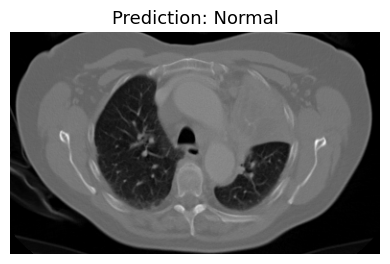

In [25]:
# ── Optional — visualise the sample image ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if sample_images:
    img = mpimg.imread(sample)
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray' if img.ndim == 2 else None)
    plt.title(f"Prediction: {result[0]['image']}", fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

---
## 📦 Package & Download Artifacts
Zips all stage outputs and downloads them so you can retrieve them from Colab.

In [26]:
import shutil, os

# ── Stage 1 output: data_ingestion folder ────────────────────────────────────
shutil.make_archive(
    '/content/stage1_data_ingestion',
    'zip',
    root_dir='artifacts',
    base_dir='data_ingestion'
)
print('✅ stage1_data_ingestion.zip created.')

✅ stage1_data_ingestion.zip created.


In [27]:
# ── Stage 2 output: prepare_base_model folder ─────────────────────────────────
shutil.make_archive(
    '/content/stage2_prepare_base_model',
    'zip',
    root_dir='artifacts',
    base_dir='prepare_base_model'
)
print('✅ stage2_prepare_base_model.zip created.')

✅ stage2_prepare_base_model.zip created.


In [28]:
# ── Stage 3 output: training folder ──────────────────────────────────────────
shutil.make_archive(
    '/content/stage3_trained_model',
    'zip',
    root_dir='artifacts',
    base_dir='training'
)
print('✅ stage3_trained_model.zip created.')

✅ stage3_trained_model.zip created.


In [29]:
# ── Stage 4 output: scores.json + logs ───────────────────────────────────────
import zipfile

with zipfile.ZipFile('/content/stage4_evaluation.zip', 'w') as zf:
    zf.write('scores.json')
    for log_file in glob.glob('logs/**', recursive=True):
        if os.path.isfile(log_file):
            zf.write(log_file)

print('✅ stage4_evaluation.zip created (scores.json + logs).')

✅ stage4_evaluation.zip created (scores.json + logs).


In [30]:
# ── Full project artifacts bundle ─────────────────────────────────────────────
shutil.make_archive(
    '/content/all_artifacts',
    'zip',
    root_dir=PROJECT_DIR,
    base_dir='artifacts'
)
print('✅ all_artifacts.zip created — contains every stage output.')

✅ all_artifacts.zip created — contains every stage output.


In [31]:
# ── Trigger browser downloads ─────────────────────────────────────────────────
from google.colab import files

zips_to_download = [
    '/content/stage1_data_ingestion.zip',
    '/content/stage2_prepare_base_model.zip',
    '/content/stage3_trained_model.zip',
    '/content/stage4_evaluation.zip',
    '/content/all_artifacts.zip',
]

for z in zips_to_download:
    size_mb = os.path.getsize(z) / (1024 ** 2)
    print(f"  ⬇️  {os.path.basename(z)}  ({size_mb:.1f} MB)")
    files.download(z)

print('\n✅ All downloads triggered.')

  ⬇️  stage1_data_ingestion.zip  (93.4 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  stage2_prepare_base_model.zip  (104.6 MB)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  all_artifacts.zip  (250.3 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All downloads triggered.


---
## ✅ Run Summary

| Stage | Description | Output |
|-------|-------------|--------|
| 1 | Data Ingestion | `artifacts/data_ingestion/Chest-CT-Scan-data/` |
| 2 | Prepare Base Model | `artifacts/prepare_base_model/base_model_updated.h5` |
| 3 | Model Training | `artifacts/training/model.h5` |
| 4 | Evaluation + MLflow | `scores.json` + DagsHub run |

**MLflow Dashboard:** check your DagsHub repo → *Experiments* tab to see the logged run with params, loss, and accuracy.

> AWS EC2 deployment (Docker + GitHub Actions) is handled outside this notebook — see `.github/workflows/main.yaml` in the project repo.